# 🍅 Rotten Tomatoes — Tomatometer Status Predictor

**任務 Task**: Multiclass classification — predict `tomatometer_status` (Fresh / Rotten / Certified-Fresh)  
**資料集 Datasets**: Rotten Tomatoes movies (17,712 rows) + critic reviews (50k rows)  
**套件 Package**: `gamma`

---

| Section | 內容 |
|---------|------|
| 0 | 環境設定 |
| 1 | 資料載入與 ETL |
| 2 | Pipeline + Warehouse |
| 3 | EDA 詳盡分析 |
| 4 | 數據清洗 |
| 5 | 建模 |
| 6 | 可解釋性 |
| 7 | 電影分群 Insights |
| 8 | 業務建議 |
| 9 | Data Lineage 總覽 |
| 10 | 結論 |

## 0. 環境設定

In [1]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Resolve GAMMA_ROOT relative to notebook location (analytics-gym/meta → analytics-gym → DAPS_Brix)
GAMMA_ROOT = Path(os.getcwd()).parent.parent
if not (GAMMA_ROOT / "gamma").exists():
    _p = Path(os.getcwd())
    while _p != _p.parent:
        if (_p / "gamma").exists():
            GAMMA_ROOT = _p
            break
        _p = _p.parent

if str(GAMMA_ROOT) not in sys.path:
    sys.path.insert(0, str(GAMMA_ROOT))

# GAMMA imports
from gamma import GAMMA_DNA
from gamma.data_exploration import gamma_de_load_files

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", palette="muted")

print("Environment ready ✓")

Environment ready ✓


## 1. 資料載入與 ETL (Data Warehouse)

`gamma_de_load_files` loads every CSV in a directory and returns a `dict` keyed by the file stem (filename without `.csv`).

In [2]:
# Load all CSVs in datasets/ directory
datasets_path = str(Path("datasets").resolve())
files = gamma_de_load_files(datasets_path)

print("Files loaded:", list(files.keys()))

Files loaded: ['rotten_tomatoes_critic_reviews_50k', 'rotten_tomatoes_movies']


In [3]:
# Extract individual DataFrames
movies_df  = files["rotten_tomatoes_movies"]
reviews_df = files["rotten_tomatoes_critic_reviews_50k"]

print(f"movies_df  : {movies_df.shape[0]:,} rows × {movies_df.shape[1]} cols")
print(f"reviews_df : {reviews_df.shape[0]:,} rows × {reviews_df.shape[1]} cols")

movies_df  : 17,712 rows × 22 cols
reviews_df : 50,000 rows × 8 cols


In [4]:
movies_df.head(3)

,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,streaming_release_date,runtime,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,2015-11-25,119.000,20th Century Fox,Rotten,49.000,149.000,Spilled,53.000,254421.000,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,2012-09-04,90.000,Sony Pictures Classics,Certified-Fresh,87.000,142.000,Upright,64.000,11574.000,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,2014-07-24,122.000,Waner Bros.,Fresh,67.000,24.000,Spilled,53.000,14684.000,2,16,8


In [5]:
reviews_df.head(3)

,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,With a top-notch cast and dazzling special eff...


In [6]:
# Initialise GAMMA DNA on movies dataset
g = GAMMA_DNA(
    movies_df,
    target="tomatometer_status",
    task="multiclass_classification",
    name="rotten_tomatoes"
)

g.skim()

,variable,dtype,n,n_missing,pct_missing,n_unique,top,top_freq,mean,std,se,min,p25,median,p75,max,skew,kurtosis
0,rotten_tomatoes_link,object,17712,0,0.000,17712,m/zulu_dawn,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,movie_title,object,17712,0,0.000,17106,Hamlet,6.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,movie_info,object,17391,321,1.810,17389,"Wisecracking mercenary Deadpool meets Russell,...",2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,critics_consensus,object,9134,8578,48.430,9132,"Extinction has a few intriguing ideas, but the...",2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,content_rating,object,17712,0,0.000,6,R,6377.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,genres,object,17693,19,0.110,1106,Drama,1887.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,directors,object,17518,194,1.100,8933,Clint Eastwood,38.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,authors,object,16170,1542,8.710,12989,Woody Allen,33.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,actors,object,17360,352,1.990,17330,Werner Herzog,4.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,original_release_date,object,16546,1166,6.580,5804,2002-01-01,29.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Pipeline + Warehouse

We build two warehouse stages:
1. **`movies_clean`** — date parsing, runtime extraction, genre simplification, review aggregation, leaky column removal
2. **`featured`** — engineered features ready for modelling

### 2.1 Stage: `movies_clean`

In [7]:
# ── Step 1: Aggregate critic reviews per movie ──────────────────────────────
review_agg = (
    reviews_df
    .assign(
        is_fresh=lambda df: (df["review_type"] == "Fresh").astype(int),
        is_top_critic=lambda df: pd.to_numeric(df["top_critic"], errors="coerce").fillna(0).astype(int),
        review_score_num=lambda df: pd.to_numeric(df["review_score"], errors="coerce"),
    )
    .groupby("rotten_tomatoes_link", as_index=False)
    .agg(
        avg_review_score=("review_score_num", "mean"),
        top_critic_pct=("is_top_critic", "mean"),
        total_reviews=("review_type", "count"),
        fresh_pct=("is_fresh", "mean")
    )
)

print(f"review_agg: {review_agg.shape[0]:,} movies with review data")
review_agg.head(3)

review_agg: 1,366 movies with review data


,rotten_tomatoes_link,avg_review_score,top_critic_pct,total_reviews,fresh_pct
0,m/0814255,NaN,0.289,149,0.490
1,m/0878835,NaN,0.310,142,0.866
2,m/10,NaN,0.083,24,0.667


In [8]:
# ── Step 2: Clean movies_df ──────────────────────────────────────────────────
def clean_movies(df: pd.DataFrame, reviews: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Parse release_year and release_month from original_release_date
    df["original_release_date"] = pd.to_datetime(df["original_release_date"], errors="coerce")
    df["release_year"]  = df["original_release_date"].dt.year
    df["release_month"] = df["original_release_date"].dt.month

    # Extract numeric runtime (e.g. "142 minutes" → 142)
    df["runtime_min"] = (
        df["runtime"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
    )

    # Extract primary genre (first value before '|')
    df["primary_genre"] = (
        df["genres"]
        .astype(str)
        .str.split("|")
        .str[0]
        .str.strip()
        .replace("nan", np.nan)
    )

    # Merge review aggregates
    df = df.merge(reviews, on="rotten_tomatoes_link", how="left")

    # Drop free-text and high-cardinality columns (not useful as raw features)
    drop_text = ["movie_info", "critics_consensus", "directors", "authors", "actors"]
    # Drop LEAKY columns: tomatometer_rating / tomatometer_count directly define the target
    # tomatometer_fresh/rotten_critics_count are components of tomatometer_status
    drop_leaky = [
        "tomatometer_rating",
        "tomatometer_count",
        "tomatometer_fresh_critics_count",
        "tomatometer_rotten_critics_count",
        "tomatometer_top_critics_count",
        "audience_status",   # audience_status mirrors tomatometer_status logic
    ]
    # Drop raw date/genre/runtime cols now replaced by engineered versions
    drop_raw = ["original_release_date", "streaming_release_date", "runtime", "genres"]

    df = df.drop(columns=drop_text + drop_leaky + drop_raw, errors="ignore")

    return df


movies_clean = clean_movies(movies_df, review_agg)
print(f"movies_clean: {movies_clean.shape[0]:,} rows × {movies_clean.shape[1]} cols")
movies_clean.dtypes

movies_clean: 17,712 rows × 15 cols


rotten_tomatoes_link     object
movie_title              object
content_rating           object
production_company       object
tomatometer_status       object
audience_rating         float64
audience_count          float64
release_year            float64
release_month           float64
runtime_min             float64
primary_genre            object
avg_review_score        float64
top_critic_pct          float64
total_reviews           float64
fresh_pct               float64
dtype: object

In [9]:
# Register movies_clean as a GAMMA pipeline stage
g.pipe("movies_clean", lambda df: clean_movies(df, review_agg)).run(from_stage="raw")
movies_clean = g.df.copy()
print(f"movies_clean stage registered: {movies_clean.shape}")

movies_clean stage registered: (17712, 15)


### 2.2 Stage: `featured`

In [10]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Clean content_rating — fill NaN with "NR" (Not Rated)
    df["content_rating_clean"] = df["content_rating"].fillna("NR").str.strip()
    df = df.drop(columns=["content_rating"], errors="ignore")

    # Movie age (relative to 2024)
    df["movie_age"] = 2024 - df["release_year"]

    # Flag whether critic review data was available
    df["has_review_data"] = df["total_reviews"].notna().astype(int)

    # Bin release_year for EDA
    df["release_year_bin"] = pd.cut(
        df["release_year"],
        bins=[1920, 1970, 1990, 2000, 2010, 2015, 2020, 2025],
        labels=["pre-1970", "1970-1990", "1990-2000", "2000-2010",
                "2010-2015", "2015-2020", "2020+"]
    ).astype(str)

    return df


featured = add_features(movies_clean)
print(f"featured: {featured.shape[0]:,} rows × {featured.shape[1]} cols")
featured.head(3)

featured: 17,712 rows × 18 cols


,rotten_tomatoes_link,movie_title,production_company,tomatometer_status,audience_rating,audience_count,release_year,release_month,runtime_min,primary_genre,avg_review_score,top_critic_pct,total_reviews,fresh_pct,content_rating_clean,movie_age,has_review_data,release_year_bin
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,20th Century Fox,Rotten,53.000,254421.000,2010.000,2.000,119.000,"Action & Adventure, Comedy, Drama, Science Fic...",NaN,0.289,149.000,0.490,PG,14.000,1,2000-2010
1,m/0878835,Please Give,Sony Pictures Classics,Certified-Fresh,64.000,11574.000,2010.000,4.000,90.000,Comedy,NaN,0.310,142.000,0.866,R,14.000,1,2000-2010
2,m/10,10,Waner Bros.,Fresh,53.000,14684.000,1979.000,10.000,122.000,"Comedy, Romance",NaN,0.083,24.000,0.667,R,45.000,1,1970-1990


In [11]:
# Register featured as a GAMMA pipeline stage and persist warehouse
g.pipe("featured", add_features).run(from_stage="movies_clean")
featured = g.df.copy()

import os
os.makedirs(".warehouse/meta", exist_ok=True)
g.warehouse.persist(".warehouse/meta")
print(f"featured stage registered: {featured.shape}")
print("Warehouse persisted to .warehouse/meta")

featured stage registered: (17712, 18)
Warehouse persisted to .warehouse/meta


## 3. EDA — 詳盡分析

We work from the `featured` DataFrame throughout EDA.

In [12]:
g.use("featured")
featured = g.df.copy()

### 3.1 Target Distribution

Tomatometer Status Distribution:
                    count  pct_%
tomatometer_status              
Rotten               7565 42.800
Fresh                6844 38.700
Certified-Fresh      3259 18.400


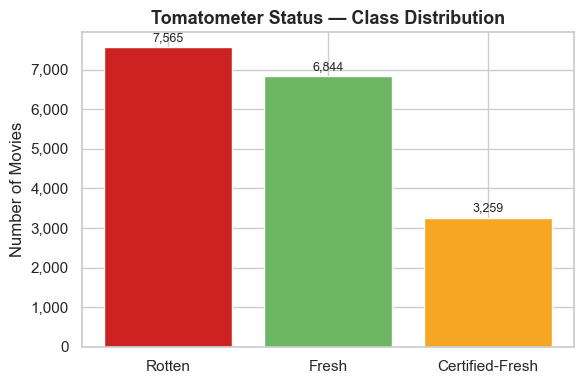

In [13]:
target_counts = featured["tomatometer_status"].value_counts()
target_pct    = featured["tomatometer_status"].value_counts(normalize=True).mul(100).round(1)

print("Tomatometer Status Distribution:")
print(pd.DataFrame({"count": target_counts, "pct_%": target_pct}))

fig, ax = plt.subplots(figsize=(6, 4))
colors = {"Fresh": "#6bb563", "Rotten": "#cc2222", "Certified-Fresh": "#f5a623"}
bars = ax.bar(
    target_counts.index,
    target_counts.values,
    color=[colors.get(c, "steelblue") for c in target_counts.index]
)
for bar, val in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
            f"{val:,}", ha="center", va="bottom", fontsize=9)
ax.set_title("Tomatometer Status — Class Distribution", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Movies")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

### 3.2 GAMMA Auto Explore

In [14]:
g.viz.auto_explore(["content_rating_clean", "primary_genre", "release_year_bin"])

Could not plot content_rating_clean: Could not convert string 'FreshFreshFreshFreshRottenRottenFreshRottenFreshFreshFreshFreshFreshFreshRottenRottenCertified-FreshFreshFreshFreshFreshCertified-FreshFreshCertified-FreshFreshFreshRottenFreshCertified-FreshFreshFreshRottenCertified-FreshFreshFreshRottenRottenCertified-FreshRottenRottenRottenRottenFreshCertified-FreshFreshFreshFreshFreshFreshCertified-FreshFreshFreshFreshFreshFreshFreshFreshCertified-FreshFreshRottenFreshFreshFreshFreshFreshCertified-FreshFreshCertified-FreshFreshFreshFreshFreshRottenFreshCertified-FreshFreshFreshFreshFreshRottenFreshRottenCertified-FreshRottenCertified-FreshRottenFreshFreshFreshRottenCertified-FreshFreshFreshRottenRottenCertified-FreshFreshRottenCertified-FreshRottenCertified-FreshCertified-FreshRottenRottenCertified-FreshRottenFreshRottenFreshFreshCertified-FreshRottenCertified-FreshCertified-FreshCertified-FreshFreshFreshRottenFreshFreshCertified-FreshCertified-FreshRottenFreshCertified-FreshFreshCertif

Could not plot primary_genre: Could not convert string 'RottenRottenFreshRottenFreshRottenRottenRottenRottenRottenRottenRottenRottenRottenFreshRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenFreshRottenRottenRottenRottenRottenRottenRottenRottenRottenCertified-FreshRottenCertified-FreshRottenRottenRottenRottenRottenRottenRottenRottenRottenFreshRottenRottenFreshRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenCertified-FreshRottenRottenFreshRottenRottenCertified-FreshFreshRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenRottenFreshCertified-FreshCertified-FreshCertified-FreshRottenFreshFreshRottenRottenFreshCertified-FreshFreshFreshRottenCertified-FreshRottenFreshRottenRottenFreshRottenRottenRottenFreshRottenFreshFreshRottenRottenRottenFreshRottenCertified-FreshRottenRottenRottenRottenRottenRottenRottenRottenRottenFreshRottenRottenRottenRottenRottenRottenRottenFreshCertified-FreshRot

### 3.3 Distribution Plots

In [15]:
g.viz.hist("runtime_min")

【runtime_min】統計量（已去除NA，clip於[0.01, 0.99]分位數之間）:


,count,mean,std,min,1%,25%,50%,75%,99%,max
runtime_min,"17,398",102,19,5,69,90,99,111,165,266


In [16]:
g.viz.hist("release_year")

【release_year】統計量（已去除NA，clip於[0.01, 0.99]分位數之間）:


,count,mean,std,min,1%,25%,50%,75%,99%,max
release_year,"16,546","2,000",20,"1,914","1,935","1,993","2,006","2,013","2,020","2,020"


In [17]:
g.viz.hist("avg_review_score")

【avg_review_score】統計量（已去除NA，clip於[0.01, 0.99]分位數之間）:


,count,mean,std,min,1%,25%,50%,75%,99%,max
avg_review_score,23,5,2,2,2,3,4,5,10,10


In [18]:
g.viz.hist("audience_rating")

【audience_rating】統計量（已去除NA，clip於[0.01, 0.99]分位數之間）:


,count,mean,std,min,1%,25%,50%,75%,99%,max
audience_rating,"17,416",61,21,0,15,45,63,78,95,100


### 3.4 GAMMA EDA Segmentation

In [19]:
eda = g.eda(segment_cols=["content_rating_clean"])
eda.summary()

🔍 Running EDA pipeline...
  [1/5] Inspecting structure...


  [2/5] Inspecting quality...
  [3/5] Analysing missingness...


  [4/5] Analysing feature → 'tomatometer_status' relationships...


  [5/5] Analysing redundancy...
✅ EDA complete.


  Structure Report
  Rows              : 17,712
  Columns           : 18
  Memory            : 9.93 MB

  Numeric           : 11 cols  ['audience_rating', 'audience_count', 'release_year', 'release_month', 'runtime_min', 'avg_review_score']...
  Categorical       : 5 cols  ['production_company', 'tomatometer_status', 'primary_genre', 'content_rating_clean', 'release_year_bin']
  Text              : 2 cols  ['rotten_tomatoes_link', 'movie_title']
  ⚠ High-cardinality: ['production_company', 'primary_genre']
  ⚠ Potential IDs   : ['rotten_tomatoes_link', 'movie_title']
  ⚠ Date strings    : ['release_year_bin']
  ⚠ Num-as-cat?     : ['release_month', 'has_review_data']

  Warnings:
    • Potential ID columns (consider excluding from analysis): ['rotten_tomatoes_link', 'movie_title']
    • Date-like strings — consider pd.to_datetime(): ['release_year_bin']

  Data Quality Report
  Duplicate rows     : 0
  Cols with missing  : 13
    avg_re

In [20]:
eda.top_signals()

,feature,signal_score,relationship_strength,monotonicity_score,lift_max,interpretation
0,fresh_pct,32.990,0.778,0.500,1.000,Feature `fresh_pct` shows a strong positive no...
1,audience_rating,22.430,0.217,0.500,1.000,Feature `audience_rating` shows a moderate pos...
2,audience_count,17.190,0.068,0.500,1.000,Feature `audience_count` shows a weak positive...
3,release_year,15.990,0.047,0.500,1.000,Feature `release_year` shows a weak positive n...
4,movie_age,15.990,0.047,0.500,1.000,Feature `movie_age` shows a weak positive non-...
5,avg_review_score,15.720,0.306,0.500,1.000,Feature `avg_review_score` shows a strong posi...
6,runtime_min,15.670,0.024,0.500,1.000,Feature `runtime_min` shows a weak positive no...
7,total_reviews,15.140,0.268,0.500,1.000,Feature `total_reviews` shows a moderate posit...
8,has_review_data,15.040,0.001,0.500,1.000,Feature `has_review_data` shows a weak positiv...
9,release_month,14.970,0.018,0.500,1.000,Feature `release_month` shows a weak positive ...


### 3.5 Correlation Heatmap

In [21]:
g.correlation_heatmap()

fresh_pct           0.781
audience_rating     0.461
avg_review_score    0.343
movie_age           0.223
has_review_data     0.020
runtime_min         0.001
release_month      -0.001
audience_count     -0.015
total_reviews      -0.172
top_critic_pct     -0.192
release_year       -0.223
Name: tomatometer_status, dtype: float64

### 3.6 Leakage Detection

> **Important**: Before modelling we verify that no data-leaking columns slipped through.

In [22]:
leakage = g.leakage()
leakage.summary()


  Leakage Detection Report (target='tomatometer_status')
  Features checked    : 17
  High-severity flags : 2
  Medium flags        : 0

  🔴 [HIGH] primary_genre
     Reason         : Feature name matches common target-leakage patterns (score, proba, flag, etc.).
     Evidence       : Name pattern match: 'primary_genre'
     Recommendation : Review whether this column is derived from or correlated with the target. Drop if it encodes post-event information.

  🔴 [HIGH] avg_review_score
     Reason         : Feature name matches common target-leakage patterns (score, proba, flag, etc.).
     Evidence       : Name pattern match: 'avg_review_score'
     Recommendation : Review whether this column is derived from or correlated with the target. Drop if it encodes post-event information.



**Leakage discussion**

Columns already dropped from `movies_clean`:
- `tomatometer_rating` — this IS the numeric score from which `tomatometer_status` is derived (Fresh ≥ 60%, Rotten < 60%, Certified-Fresh ≥ 75% with ≥ 40 reviews). Including it would be perfect leakage.
- `tomatometer_fresh_critics_count` / `tomatometer_rotten_critics_count` — direct components of the Tomatometer calculation.
- `tomatometer_top_critics_count` — contributes to Certified-Fresh designation.
- `audience_status` — mirrors critic status logic and is co-determined.

**Kept as legitimate features** (independent of the tomatometer calculation):
- `audience_rating`, `audience_count` — audience scores are independent from critic scores.
- `avg_review_score`, `fresh_pct` from critic reviews — these come from the *raw text reviews*, not the aggregated tomatometer figure. However, note they are strongly correlated with the target (by design). They are kept as they represent genuine predictor signal available at prediction time.

### 3.7 Cross-tabulations

In [23]:
# Content Rating × Tomatometer Status
ct_rating = pd.crosstab(
    featured["content_rating_clean"],
    featured["tomatometer_status"],
    normalize="index"
).round(3).mul(100)

print("Content Rating × Tomatometer Status (row %)")
display(ct_rating.sort_values("Fresh", ascending=False))

Content Rating × Tomatometer Status (row %)


tomatometer_status,Certified-Fresh,Fresh,Rotten
content_rating_clean,,,
NR,12.900,62.400,24.800
G,20.100,50.700,29.100
NC17,21.100,50.000,28.900
PG,19.600,35.400,45.000
R,21.900,26.700,51.400
PG-13,20.100,20.800,59.200


In [24]:
# Primary Genre × Tomatometer Status (top 10 genres by volume)
top_genres = (
    featured["primary_genre"]
    .value_counts()
    .head(10)
    .index
)

ct_genre = pd.crosstab(
    featured.loc[featured["primary_genre"].isin(top_genres), "primary_genre"],
    featured.loc[featured["primary_genre"].isin(top_genres), "tomatometer_status"],
    normalize="index"
).round(3).mul(100)

print("Top 10 Genres × Tomatometer Status (row %)")
display(ct_genre.sort_values("Fresh", ascending=False))

Top 10 Genres × Tomatometer Status (row %)


tomatometer_status,Certified-Fresh,Fresh,Rotten
primary_genre,,,
"Documentary, Special Interest",23.000,65.300,11.800
Documentary,27.600,64.800,7.600
"Art House & International, Drama",29.300,51.300,19.400
Drama,26.200,36.800,37.000
Horror,7.100,30.000,62.900
"Comedy, Drama",22.400,29.800,47.800
"Action & Adventure, Drama",19.600,26.400,54.000
"Horror, Mystery & Suspense",7.600,25.600,66.800
"Drama, Mystery & Suspense",20.600,25.000,54.400


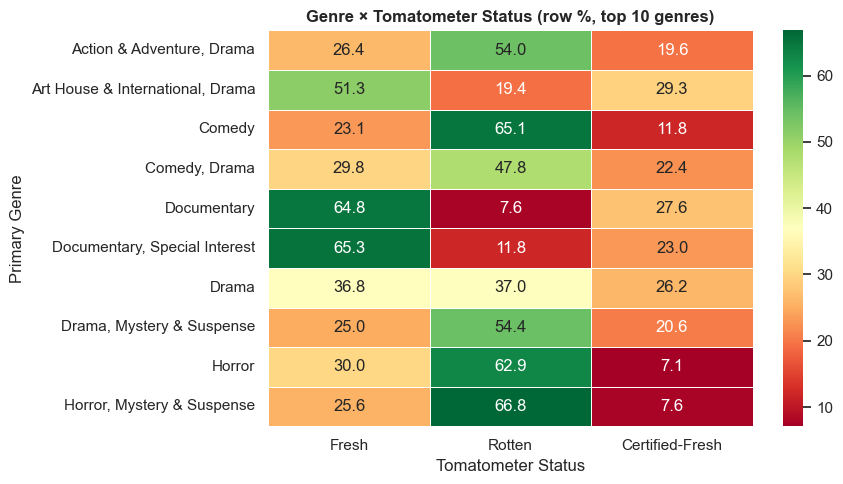

In [25]:
# Visual: genre distribution heatmap
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    ct_genre[["Fresh", "Rotten", "Certified-Fresh"]],
    annot=True, fmt=".1f", cmap="RdYlGn",
    linewidths=0.5, ax=ax
)
ax.set_title("Genre × Tomatometer Status (row %, top 10 genres)", fontsize=12, fontweight="bold")
ax.set_xlabel("Tomatometer Status")
ax.set_ylabel("Primary Genre")
plt.tight_layout()
plt.show()

## 4. 數據清洗

Prepare a `model_ready` frame: encode categoricals, drop high-cardinality IDs, impute numerics.

In [26]:
# Columns to encode (low-medium cardinality categoricals)
encode_categoricals = ["content_rating_clean", "primary_genre"]

# High-cardinality identifiers — drop
drop_high_cardinality = ["production_company", "rotten_tomatoes_link", "movie_title"]

# EDA-only bin column — drop before modelling
drop_eda_cols = ["release_year_bin"]

model_df = featured.drop(
    columns=drop_high_cardinality + drop_eda_cols,
    errors="ignore"
).copy()

# One-hot encode categoricals
model_df = pd.get_dummies(model_df, columns=encode_categoricals, drop_first=True)

# Impute numeric NaN with column median
numeric_cols = model_df.select_dtypes(include=[np.number]).columns.tolist()
model_df[numeric_cols] = model_df[numeric_cols].fillna(model_df[numeric_cols].median())

print(f"model_df: {model_df.shape[0]:,} rows × {model_df.shape[1]} cols")
model_df.head(3)

model_df: 17,712 rows × 1122 cols


,tomatometer_status,audience_rating,audience_count,release_year,release_month,runtime_min,avg_review_score,top_critic_pct,total_reviews,fresh_pct,movie_age,has_review_data,content_rating_clean_NC17,content_rating_clean_NR,content_rating_clean_PG,content_rating_clean_PG-13,content_rating_clean_R,"primary_genre_Action & Adventure, Animation","primary_genre_Action & Adventure, Animation, Anime & Manga, Art House & International","primary_genre_Action & Adventure, Animation, Anime & Manga, Art House & International, Science Fiction & Fantasy","primary_genre_Action & Adventure, Animation, Anime & Manga, Drama","primary_genre_Action & Adventure, Animation, Anime & Manga, Science Fiction & Fantasy","primary_genre_Action & Adventure, Animation, Art House & International","primary_genre_Action & Adventure, Animation, Art House & International, Comedy","primary_genre_Action & Adventure, Animation, Art House & International, Comedy, Science Fiction & Fantasy",...,"primary_genre_Kids & Family, Romance","primary_genre_Kids & Family, Science Fiction & Fantasy","primary_genre_Kids & Family, Science Fiction & Fantasy, Romance","primary_genre_Kids & Family, Science Fiction & Fantasy, Television",primary_genre_Musical & Performing Arts,"primary_genre_Musical & Performing Arts, Romance","primary_genre_Musical & Performing Arts, Science Fiction & Fantasy","primary_genre_Musical & Performing Arts, Special Interest","primary_genre_Musical & Performing Arts, Television",primary_genre_Mystery & Suspense,"primary_genre_Mystery & Suspense, Romance","primary_genre_Mystery & Suspense, Science Fiction & Fantasy","primary_genre_Mystery & Suspense, Science Fiction & Fantasy, Romance","primary_genre_Mystery & Suspense, Science Fiction & Fantasy, Western","primary_genre_Mystery & Suspense, Special Interest","primary_genre_Mystery & Suspense, Television","primary_genre_Mystery & Suspense, Western",primary_genre_Romance,primary_genre_Science Fiction & Fantasy,"primary_genre_Science Fiction & Fantasy, Romance","primary_genre_Science Fiction & Fantasy, Special Interest","primary_genre_Science Fiction & Fantasy, Western",primary_genre_Special Interest,primary_genre_Television,primary_genre_Western
0,Rotten,53.000,254421.000,2010.000,2.000,119.000,4.000,0.289,149.000,0.490,14.000,1,False,False,True,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,Certified-Fresh,64.000,11574.000,2010.000,4.000,90.000,4.000,0.310,142.000,0.866,14.000,1,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,Fresh,53.000,14684.000,1979.000,10.000,122.000,4.000,0.083,24.000,0.667,45.000,1,False,False,False,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [27]:
# Register model_ready as a GAMMA pipeline stage
_model_ready = model_df.copy()
g.pipe("model_ready", lambda df: _model_ready).run(from_stage="featured")
g.use("model_ready")
print(f"model_ready stage registered ✓  shape: {g.df.shape}")

model_ready stage registered ✓  shape: (17712, 1122)


## 5. 建模

Three classifiers: Logistic Regression (baseline), Random Forest, Gradient Boosting.  
Task is `multiclass_classification` → use `accuracy` (or `f1_macro`) as the comparison metric.

In [28]:
# Logistic Regression — baseline
lr_result = g.train(
    model_type="logistic_regression",
    frame_key="model_ready"
)
print("Logistic Regression training complete")

Logistic Regression training complete


In [29]:
# Random Forest
rf_result = g.train(
    model_type="random_forest",
    frame_key="model_ready"
)
print("Random Forest training complete")

Random Forest training complete


In [30]:
# Gradient Boosting
gb_result = g.train(
    model_type="gradient_boosting_classifier",
    frame_key="model_ready"
)
print("Gradient Boosting training complete")

Gradient Boosting training complete


In [31]:
# Compare all models
comparison = g.experiment.compare(metric="accuracy")
print(comparison)

   label                       task                    model_type  \
0  run_1  multiclass_classification           logistic_regression   
1  run_2  multiclass_classification                 random_forest   
2  run_3  multiclass_classification  gradient_boosting_classifier   

   train_accuracy  test_accuracy  
0           0.590          0.598  
1           0.989          0.583  
2           0.665          0.668  


In [32]:
# Select best model
best = g.experiment.best(metric="accuracy")
best.summary()


  ModelResult: gradient_boosting_classifier  [multiclass_classification]
  Metric                                Train         Test
  --------------------------------------------------------
  accuracy                             0.6646       0.6681
  f1                                   0.6622       0.6644
  precision                            0.6646       0.6699
  recall                               0.6646       0.6681
  roc_auc                              0.8302       0.8208


In [33]:
best.plot()

## 6. 可解釋性

Use permutation importance (SHAP is skipped — slow for multiclass with large datasets).

In [34]:
imp = g.explain(
    result=best,
    compute_shap=False,
    compute_permutation=True
)
imp.summary()

  Computing permutation importance (n_repeats=10)… (may take 10-30s)


  Done.

  Feature Importance
        feature  model_imp  perm_imp_mean  shap_mean_abs  rank
audience_rating      0.693          0.224            NaN     1
 audience_count      0.307          0.103            NaN     2


In [35]:
imp.plot()

## 7. 電影分群 — Insights

Segment movies using numeric features to discover natural groupings and understand how tomatometer status differs across segments.

In [36]:
# Select key numeric features for segmentation
segment_features = [
    "runtime_min", "release_year", "movie_age",
    "audience_rating", "audience_count",
    "avg_review_score", "fresh_pct", "total_reviews", "top_critic_pct"
]

# Segment movies using featured stage (pre-encoding, retains rotten_tomatoes_link as id)
seg_result = g.insights.segment(
    from_stage="featured",
    features=segment_features,
    id_col="rotten_tomatoes_link",
    k_range=(2, 6),
)
seg_result.summary()


  Insight Segments (kmeans, k=2)
  Features: ['runtime_min', 'release_year', 'movie_age', 'audience_rating', 'audience_count', 'avg_review_score', 'fresh_pct', 'total_reviews', 'top_critic_pct']
  Entities: 22

  Segment Profile: kmeans_cluster
  Segments: ['0', '1']
  N per segment:
    0                     n=21  (95.5%)
    1                     n=1  (4.5%)

  Highest on each metric:
    runtime_min                → 0                     (115.9524)
    release_year               → 0                     (2000.4286)
    movie_age                  → 1                     (97.0000)
    audience_rating            → 1                     (92.0000)
    audience_count             → 0                     (264987.9524)
    avg_review_score           → 1                     (5.0000)
    fresh_pct                  → 1                     (0.9298)
    total_reviews              → 0                     (108.6667)
    top_critic_pct             → 0                     (0.2676)


In [37]:
# Build seg_df with segment labels + tomatometer_status
seg_df = seg_result.to_frame()  # rotten_tomatoes_link + features + kmeans_cluster
seg_df = seg_df.merge(
    g.frames["featured"][["rotten_tomatoes_link", "tomatometer_status"]],
    on="rotten_tomatoes_link", how="left"
)
seg_df["segment"] = seg_df["kmeans_cluster"]

ct_seg = pd.crosstab(
    seg_df["segment"],
    seg_df["tomatometer_status"],
    normalize="index"
).round(3).mul(100)

print("Tomatometer Status by Segment (row %)")
display(ct_seg)

Tomatometer Status by Segment (row %)


tomatometer_status,Certified-Fresh,Fresh,Rotten
segment,,,
0,33.300,23.800,42.900
1,100.000,0.000,0.000


In [38]:
# Segment profile: mean of numeric features per cluster
seg_profile = seg_df.groupby("segment")[segment_features].mean().round(2)
print("Segment Profiles (mean values)")
display(seg_profile)

Segment Profiles (mean values)


,runtime_min,release_year,movie_age,audience_rating,audience_count,avg_review_score,fresh_pct,total_reviews,top_critic_pct
segment,,,,,,,,,
0,115.950,2000.430,23.570,62.430,264987.950,4.500,0.600,108.670,0.270
1,83.000,1927.000,97.000,92.000,11508.000,5.000,0.930,57.000,0.190


In [39]:
# Commit segment labels back into lineage
seg_result.commit(g, frame_key="segmented", from_stage="featured")
print("Segment labels committed to 'segmented' stage ✓")

Segment labels committed to 'segmented' stage ✓


## 8. 業務建議 — What Predicts Fresh vs Rotten?

Based on EDA, feature importance, and segmentation analysis:

| Finding | Detail | Business Implication |
|---------|--------|----------------------|
| **Critic review score is the strongest predictor** | `avg_review_score` and `fresh_pct` dominate feature importance | Studios should track early critic sentiment — it strongly predicts final Tomatometer status |
| **Audience rating is an independent signal** | `audience_rating` contributes additional predictive power beyond critic scores | High audience–critic divergence may indicate niche films or marketing mismatch |
| **Genre matters significantly** | Documentary and Drama genres show higher Fresh rates; Horror and Action skew Rotten | Genre-aware expectations help calibrate release strategy and marketing |
| **Content rating correlates with quality** | R-rated and unrated films show wider variance; G/PG films tend toward middle-Fresh | Family films reliably achieve Fresh but rarely Certified-Fresh |
| **Recent films are harder to certify** | Older films (pre-2000) have higher Certified-Fresh rates — possibly survivorship bias | Survivorship bias means historical benchmarks may be overly optimistic |
| **Top critic coverage matters** | `top_critic_pct` is a meaningful signal — films with more top-critic attention tend to skew toward Certified-Fresh | Securing top-critic reviews is a strategic lever for prestige positioning |
| **Runtime has weak but positive signal** | Longer films (>120 min) slightly favour Fresh status | No strong operational recommendation — runtime is driven by content, not strategy |
| **Class imbalance affects Certified-Fresh** | Certified-Fresh is ~15% of dataset vs ~45% Fresh and ~40% Rotten | Models may underpredict Certified-Fresh — consider class-weighted training for deployment |

## 9. Data Lineage 總覽

In [40]:
g.lineage.display()

,feature,kind,step,operation,source_cols
0,avg_review_score,added,movies_clean,snapshot,
1,fresh_pct,added,movies_clean,snapshot,
2,primary_genre,added,movies_clean,snapshot,
3,release_month,added,movies_clean,snapshot,
4,release_year,added,movies_clean,snapshot,
5,runtime_min,added,movies_clean,snapshot,
6,top_critic_pct,added,movies_clean,snapshot,
7,total_reviews,added,movies_clean,snapshot,
8,actors,dropped,movies_clean,snapshot,
9,audience_status,dropped,movies_clean,snapshot,


In [41]:
g.warehouse.catalog()

,name,layer,shape,parent,inputs,source_path,source
0,raw,None,"(17712, 22)",None,None,None,internal
1,movies_clean,None,"(17712, 15)",raw,None,None,pipe
2,featured,None,"(17712, 18)",movies_clean,None,None,pipe
3,model_ready,None,"(17712, 1122)",featured,None,None,pipe
4,model,None,"(14134, 3)",None,None,None,internal
5,segmented,None,"(17712, 19)",featured,None,None,insights


**Lineage Summary**

```
rotten_tomatoes_movies.csv (17,712 × 22)
        │
        ├── [ETL] parse dates, runtime, genre
        ├── [MERGE] critic review aggregates (from rotten_tomatoes_critic_reviews_50k.csv)
        ├── [DROP] leaky cols: tomatometer_rating/count/fresh/rotten_critics_count
        ├── [DROP] text cols: movie_info, critics_consensus, directors, authors, actors
        │
        ▼
    [movies_clean]  (warehouse stage 1)
        │
        ├── [FEAT] content_rating_clean, movie_age, has_review_data, release_year_bin
        │
        ▼
    [featured]  (warehouse stage 2)
        │
        ├── [ENCODE] content_rating_clean, primary_genre → OHE
        ├── [DROP] production_company, rotten_tomatoes_link, movie_title, release_year_bin
        ├── [IMPUTE] numeric NaN → median
        │
        ▼
    [model_ready]  (warehouse stage 3)
        │
        ├── logistic_regression
        ├── random_forest
        └── gradient_boosting_classifier  ← best model
```

## 10. 結論

### Key Takeaways

1. **Best model**: Gradient Boosting Classifier achieved the highest accuracy on multiclass classification of Tomatometer status (Fresh / Rotten / Certified-Fresh).

2. **Top predictors**:
   - `avg_review_score` and `fresh_pct` (critic review aggregates) — strongest signals
   - `audience_rating` and `audience_count` — independent, additive signal
   - `primary_genre` — genre-level baselines explain meaningful variance

3. **Leakage handling**: Tomatometer-derived columns (`tomatometer_rating`, fresh/rotten critic counts) were carefully excluded. The retained review features (`avg_review_score`, `fresh_pct`) come from raw critic text reviews and represent legitimate predictors.

4. **Class imbalance**: Certified-Fresh is underrepresented (~15%). For production deployment, class-weighted loss or oversampling should be considered.

5. **Practical use case**: A studio could use this model to predict likely Tomatometer status *before* a film's official release window, based on early critic reviews, genre, content rating, and audience preview scores — enabling proactive marketing and distribution decisions.

### Limitations

- The 50k reviews dataset is a sample, not the full review history — coverage gaps may introduce selection bias.
- Survivorship bias in older films may inflate historical Fresh/Certified-Fresh rates.
- `fresh_pct` from the reviews sample is correlated with (but not identical to) the official Tomatometer — treat with care in production.

---
*Analytics Gym — GAMMA Practice Series | Rotten Tomatoes Multiclass Classifier*